# Representative NIH ChestX-ray14 X-ray Visualization (Testing)

**Purpose:** This is a *separate testing notebook* used only to produce a small representative-image visualization for the final project documentation. It does not modify the main EDA notebook (`01_nih_dataset_analysis.ipynb`), performs no additional EDA, and does not train or evaluate any model.

## Image-access approach

The KaggleHub cache contains the NIH archive at:

```
~/.cache/kagglehub/datasets/nih-chest-xrays/data/3.archive   (~1.92 GB)
```

This archive is **truncated** (the ZIP end-of-central-directory record is missing), which is why Python's `zipfile` fails with `BadZipFile`. However, `bsdtar` can still read the sequential local file headers, so **individual images can be streamed out with `bsdtar -xOf ARCHIVE <entry>` without extracting the full 1.92 GB archive**.

Only the readable early portion of the archive (`images_001/`, `images_002/`) is used. The metadata CSV (`Data_Entry_2017.csv`) is already cached, so no download is required.


---

## 1. Setup


In [1]:
import os
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

ARCHIVE = os.path.expanduser(
    "~/.cache/kagglehub/datasets/nih-chest-xrays/data/3.archive"
)
META = os.path.expanduser(
    "~/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/"
    "Data_Entry_2017.csv"
)

print("Archive exists :", os.path.exists(ARCHIVE))
print("Archive size   :", round(os.path.getsize(ARCHIVE) / 1024**3, 2), "GB")
print("Metadata exists:", os.path.exists(META))


Archive exists : True
Archive size   : 1.92 GB
Metadata exists: True


---

## 2. Locate readable entries in the truncated archive

`bsdtar -tf` lists the entries that can be reached sequentially. We keep only the image entries so we can match them against the metadata.


In [2]:
listing = subprocess.run(
    ["bsdtar", "-tf", ARCHIVE], capture_output=True, text=True
)
entries = [e.strip() for e in listing.stdout.splitlines() if e.strip()]
png_entries = [e for e in entries if e.lower().endswith(".png")]

print("Total entries readable :", len(entries))
print("PNG entries readable   :", len(png_entries))
print("First entry            :", png_entries[0])
print("Last entry             :", png_entries[-1])


Total entries readable : 5104
PNG entries readable   : 5098
First entry            : images_001/images/00000001_000.png
Last entry             : images_002/images/00001373_001.png


---

## 3. Identify representative candidates from the metadata

We use the cached metadata to find, **within the readable portion only**, clean examples of *Pneumonia* and *No Finding*, preferring distinct view positions (AP/PA).

Selection rule: single-label clean cases where possible, and different view positions where available.


In [3]:
meta = pd.read_csv(META)

readable_names = {os.path.basename(e) for e in png_entries}
readable = meta[meta["Image Index"].isin(readable_names)].copy()
print("Readable images also present in metadata:", len(readable))

pneu = readable[
    readable["Finding Labels"].str.contains("Pneumonia", case=False, na=False)
]
nofind = readable[readable["Finding Labels"] == "No Finding"]
print("Readable Pneumonia images :", len(pneu))
print("Readable No Finding images:", len(nofind))

clean_pneu = pneu[pneu["Finding Labels"] == "Pneumonia"]
print("Clean single-label Pneumonia images:", len(clean_pneu))
print()
print(clean_pneu[["Image Index", "Finding Labels", "View Position",
                 "Patient ID"]].head(10).to_string(index=False))


Readable images also present in metadata: 5098
Readable Pneumonia images : 65
Readable No Finding images: 2830
Clean single-label Pneumonia images: 18

     Image Index Finding Labels View Position  Patient ID
00000061_015.png      Pneumonia            AP          61
00000144_001.png      Pneumonia            AP         144
00000165_001.png      Pneumonia            PA         165
00000193_019.png      Pneumonia            AP         193
00000218_001.png      Pneumonia            PA         218
00000261_002.png      Pneumonia            AP         261
00000310_001.png      Pneumonia            AP         310
00000499_008.png      Pneumonia            PA         499
00000583_045.png      Pneumonia            PA         583
00000798_025.png      Pneumonia            AP         798


### Selected sample (2 Pneumonia + 2 No Finding, mixed views)


In [4]:
def pick(df, view, label_exact=None):
    sub = df[df["View Position"] == view]
    if label_exact is not None:
        sub = sub[sub["Finding Labels"] == label_exact]
    if len(sub) == 0:
        return None
    return sub.iloc[0]

selections = []
selections.append(pick(clean_pneu, "AP"))
selections.append(pick(clean_pneu, "PA"))
selections.append(pick(nofind, "AP"))
selections.append(pick(nofind, "PA"))
selections = [s for s in selections if s is not None]

sample = pd.DataFrame(selections)[
    ["Image Index", "Finding Labels", "View Position",
     "Patient ID", "Patient Age", "Patient Gender"]
].reset_index(drop=True)
print(sample.to_string(index=False))


     Image Index Finding Labels View Position  Patient ID  Patient Age Patient Gender
00000061_015.png      Pneumonia            AP          61           77              M
00000165_001.png      Pneumonia            PA         165           76              M
00000005_001.png     No Finding            AP           5           69              F
00000002_000.png     No Finding            PA           2           81              M


---

## 4. Extract only the selected images (streamed, no full extraction)

Each image is streamed directly from the archive with `bsdtar -xOf` and written to a small local cache folder. The source archive and the source images are not modified.


In [5]:
CACHE_DIR = os.path.join(os.getcwd(), "nih_sample_images")
os.makedirs(CACHE_DIR, exist_ok=True)

entry_lookup = {os.path.basename(e): e for e in png_entries}

loaded_paths = []
for fname in sample["Image Index"]:
    entry = entry_lookup[fname]
    dest = os.path.join(CACHE_DIR, fname)
    with open(dest, "wb") as fh:
        subprocess.run(["bsdtar", "-xOf", ARCHIVE, entry],
                       stdout=fh, stderr=subprocess.PIPE)
    loaded_paths.append(dest)
    ok = open(dest, "rb").read(8) == b"\x89PNG\r\n\x1a\n"
    print(f"{fname:<20} -> {os.path.getsize(dest):>8} bytes  valid PNG: {ok}")

print("\nImages extracted:", len(loaded_paths))


00000061_015.png     ->   416369 bytes  valid PNG: True
00000165_001.png     ->   452673 bytes  valid PNG: True
00000005_001.png     ->   342729 bytes  valid PNG: True
00000002_000.png     ->   402332 bytes  valid PNG: True

Images extracted: 4


### Verify each image decodes fully (grayscale)


In [6]:
for fname, path in zip(sample["Image Index"], loaded_paths):
    im = Image.open(path)
    im.load()
    arr = np.array(im)
    print(f"{fname:<20} size={im.size} mode={im.mode} "
          f"min={arr.min()} max={arr.max()} mean={arr.mean():.1f}")


00000061_015.png     size=(1024, 1024) mode=L min=0 max=255 mean=128.0
00000165_001.png     size=(1024, 1024) mode=L min=0 max=244 mean=133.3
00000005_001.png     size=(1024, 1024) mode=L min=0 max=255 mean=162.6
00000002_000.png     size=(1024, 1024) mode=L min=0 max=252 mean=180.1


---

## 5. Representative X-ray visualization (2 x 2)

Images are displayed in grayscale with axes and ticks removed. Titles show the finding label and the acquisition view position.


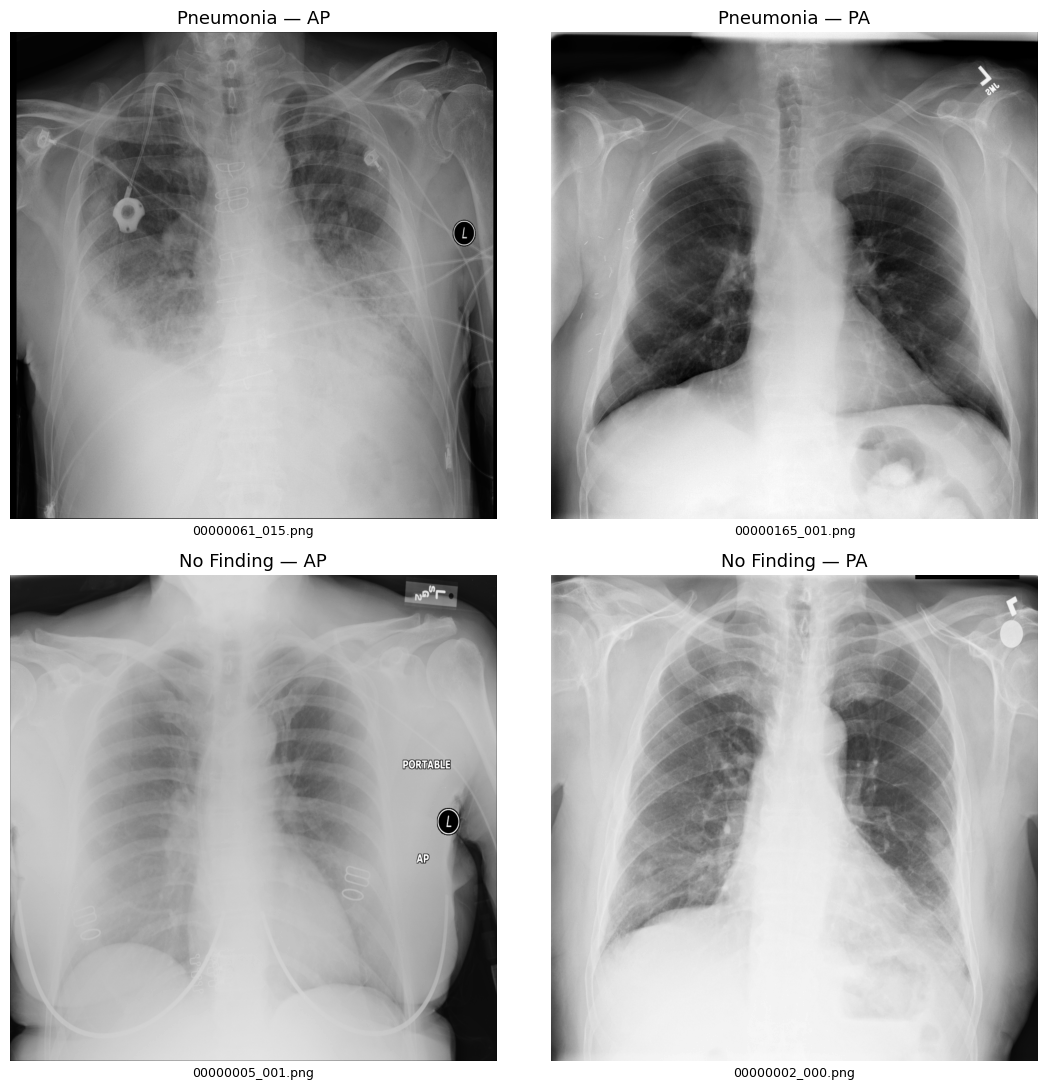

In [7]:
subplot_titles = []
for _, row in sample.iterrows():
    finding = "Pneumonia" if "Pneumonia" in row["Finding Labels"] else "No Finding"
    subplot_titles.append(f"{finding} \u2014 {row['View Position']}")

fig, axes = plt.subplots(2, 2, figsize=(11, 11))
for ax, title, fname, path in zip(axes.ravel(), subplot_titles,
                                  sample["Image Index"], loaded_paths):
    img = np.array(Image.open(path).convert("L"))
    ax.imshow(img, cmap="gray")
    ax.set_title(title, fontsize=13)
    ax.set_xlabel(fname, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.tight_layout()
plt.show()


### Optional titled version


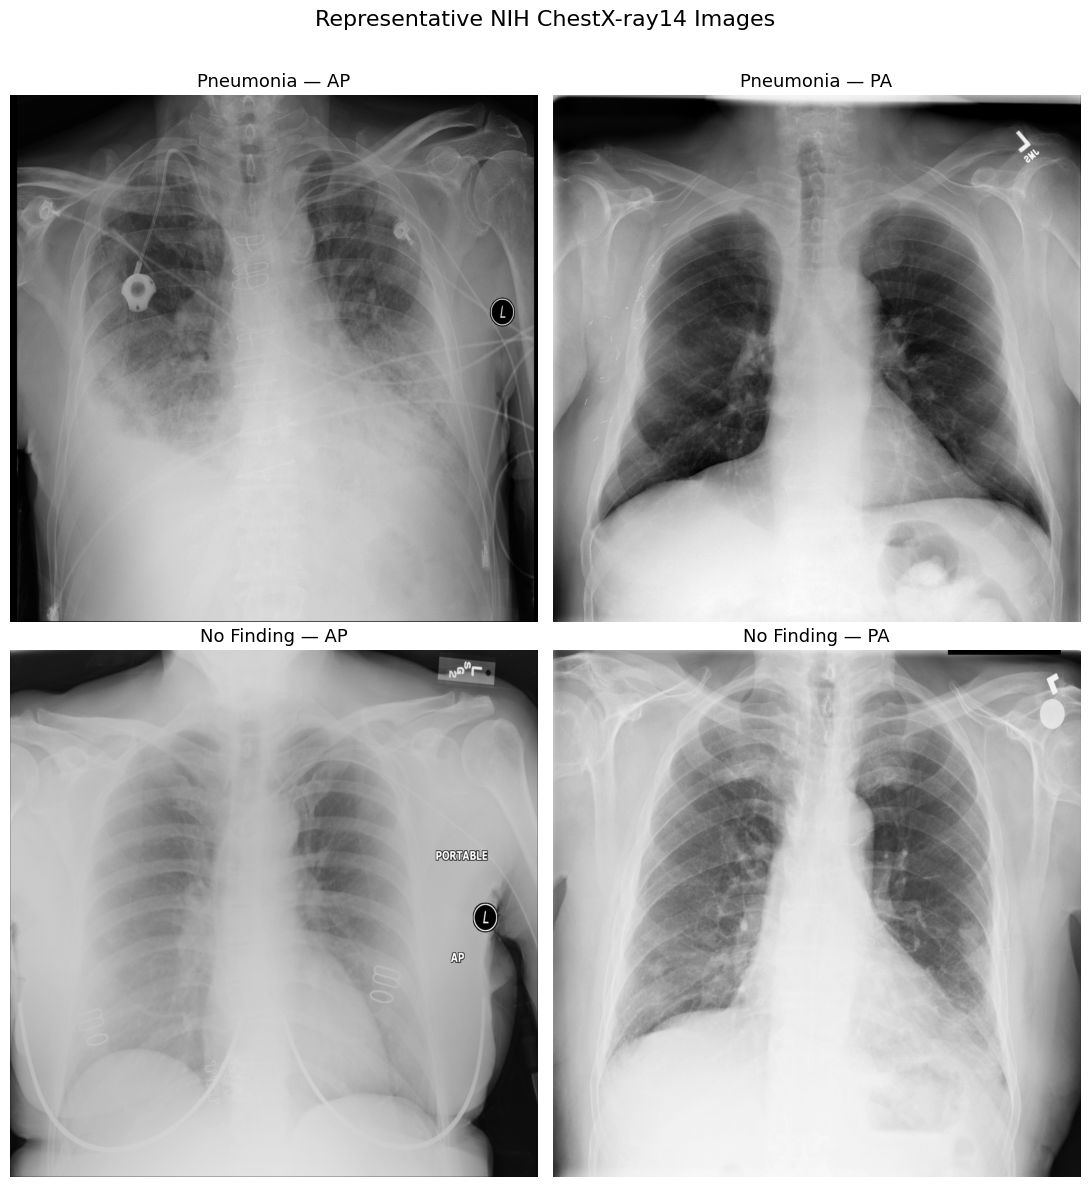

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 12))
for ax, title, fname, path in zip(axes.ravel(), subplot_titles,
                                  sample["Image Index"], loaded_paths):
    img = np.array(Image.open(path).convert("L"))
    ax.imshow(img, cmap="gray")
    ax.set_title(title, fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.suptitle("Representative NIH ChestX-ray14 Images", fontsize=16, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


---

## 6. Sample summary

The selected images, with their labels and metadata, are listed below.


In [9]:
display_cols = ["Image Index", "Finding Labels", "View Position",
                "Patient ID", "Patient Age", "Patient Gender"]
print(sample[display_cols].to_string(index=False))


     Image Index Finding Labels View Position  Patient ID  Patient Age Patient Gender
00000061_015.png      Pneumonia            AP          61           77              M
00000165_001.png      Pneumonia            PA         165           76              M
00000005_001.png     No Finding            AP           5           69              F
00000002_000.png     No Finding            PA           2           81              M


## 7. Documentation

Representative X-ray visualization was created using a small sample of NIH ChestX-ray14 images to visually inspect the image characteristics and demonstrate examples from the analyzed dataset. This visualization is descriptive and is not used for model training or evaluation.
